In [3]:
import torch
import numpy as np
from PIL import Image
from diffusers import DDIMScheduler, StableDiffusionPipeline
from pathlib import Path

class BlendedLatnetDiffusion:
    def __init__(self, device="cuda"):
        self.device = device
        # Initialize args directly instead of parsing
        self.args = type('Args', (), {
            'model_path': "stabilityai/stable-diffusion-2-1-base",
            'device': device
        })()
        self.load_models()

    def load_models(self):
        pipe = StableDiffusionPipeline.from_pretrained(
            self.args.model_path, torch_dtype=torch.float16
        )
        self.vae = pipe.vae.to(self.device)
        self.tokenizer = pipe.tokenizer
        self.text_encoder = pipe.text_encoder.to(self.device)
        self.unet = pipe.unet.to(self.device)
        self.scheduler = DDIMScheduler(
            beta_start=0.00085,
            beta_end=0.012,
            beta_schedule="scaled_linear",
            clip_sample=False,
            set_alpha_to_one=False,
        )

    @torch.no_grad()
    def edit_image(
        self,
        image_path,
        mask_path,
        prompts,
        height=512,
        width=512,
        num_inference_steps=50,
        guidance_scale=7.5,
        generator=torch.manual_seed(42),
        blending_percentage=0.25,
    ):
        batch_size = len(prompts)

        image = Image.open(image_path)
        image = image.resize((height, width), Image.BILINEAR)
        image = np.array(image)[:, :, :3]
        source_latents = self._image2latent(image)
        latent_mask, org_mask = self._read_mask(mask_path)

        text_input = self.tokenizer(
            prompts,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        text_embeddings = self.text_encoder(text_input.input_ids.to(self.device))[0]

        max_length = text_input.input_ids.shape[-1]
        uncond_input = self.tokenizer(
            [""] * batch_size,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        uncond_embeddings = self.text_encoder(uncond_input.input_ids.to(self.device))[0]
        text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

        latents = torch.randn(
            (batch_size, self.unet.in_channels, height // 8, width // 8),
            generator=generator,
        )
        latents = latents.to(self.device).half()

        self.scheduler.set_timesteps(num_inference_steps)

        for t in self.scheduler.timesteps[
            int(len(self.scheduler.timesteps) * blending_percentage) :
        ]:
            latent_model_input = torch.cat([latents] * 2)
            latent_model_input = self.scheduler.scale_model_input(
                latent_model_input, timestep=t
            )

            with torch.no_grad():
                noise_pred = self.unet(
                    latent_model_input, t, encoder_hidden_states=text_embeddings
                ).sample

            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (
                noise_pred_text - noise_pred_uncond
            )

            latents = self.scheduler.step(noise_pred, t, latents).prev_sample

            # Blending
            noise_source_latents = self.scheduler.add_noise(
                source_latents, torch.randn_like(latents), t
            )
            latents = latents * latent_mask + noise_source_latents * (1 - latent_mask)
        
        latents = 1 / 0.18215 * latents

        with torch.no_grad():
            image = self.vae.decode(latents).sample

        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
        images = (image * 255).round().astype("uint8")

        return images

    @torch.no_grad()
    def _image2latent(self, image):
        image = torch.from_numpy(image).float() / 127.5 - 1
        image = image.permute(2, 0, 1).unsqueeze(0).to(self.device)
        image = image.half()
        latents = self.vae.encode(image)["latent_dist"].mean
        latents = latents * 0.18215
        return latents

    def _read_mask(self, mask_path: str, dest_size=(64, 64)):
        org_mask = Image.open(mask_path).convert("L")
        mask = org_mask.resize(dest_size, Image.NEAREST)
        mask = np.array(mask) / 255
        mask[mask < 0.5] = 0
        mask[mask >= 0.5] = 1
        mask = mask[np.newaxis, np.newaxis, ...]
        mask = torch.from_numpy(mask).half().to(self.device)
        return mask, org_mask

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipykernel_26743/104327611.py:49: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  image = image.resize((height, width), Image.BILINEAR)
/tmp/ipykernel_26743/104327611.py:129: DeprecationWarning: NEAREST is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.NEAREST or Dither.NONE instead.
  mask = org_mask.resize(dest_size, Image.NEAREST)
/tmp/ipykernel_26743/104327611.py:74: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (batch_size, self.unet.in_channels, height // 8, width // 8),


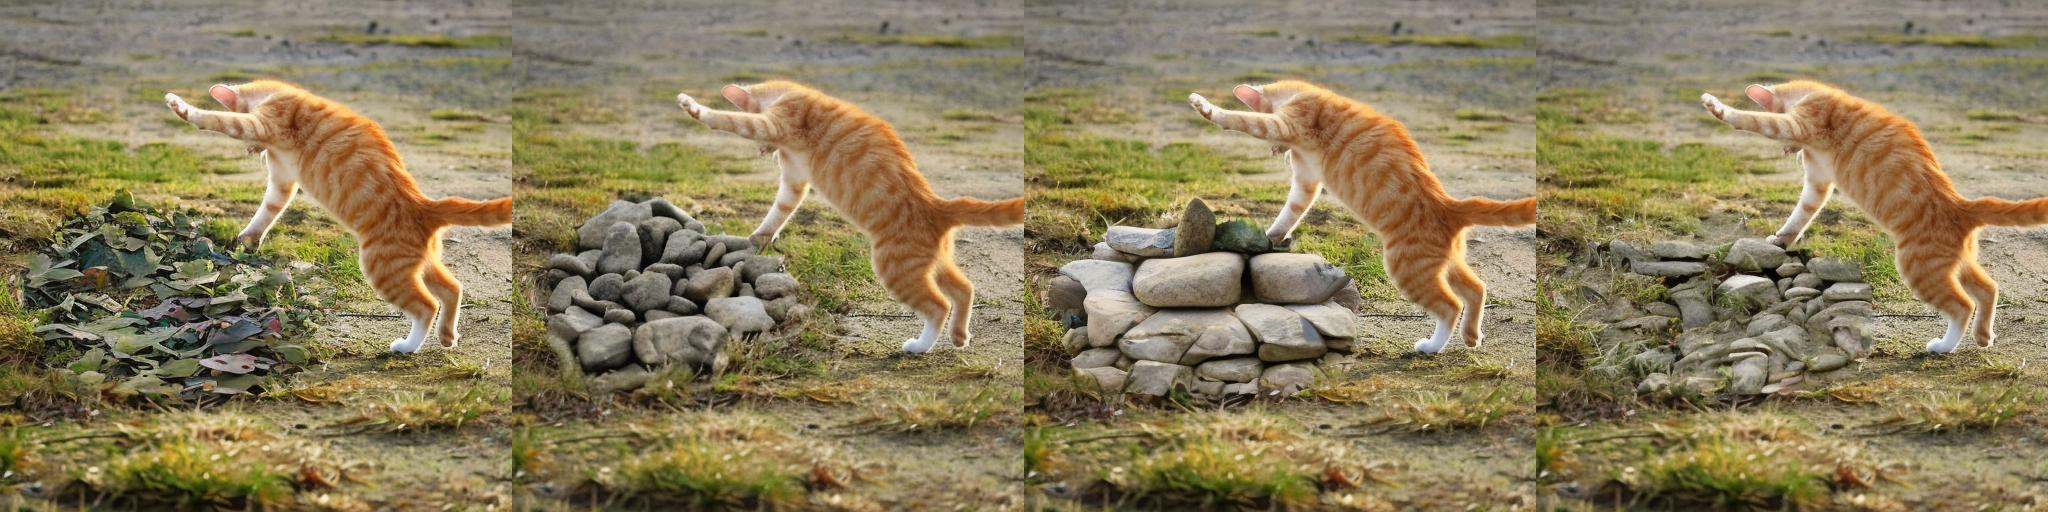

In [4]:
# Create output directory
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Initialize the model and run image editing
bld = BlendedLatnetDiffusion(device="cuda" if torch.cuda.is_available() else "cpu")

# Run the image editing
results = bld.edit_image(
    "inputs/img.png",  # Path to your input image
    "inputs/mask.png", # Path to your mask image
    prompts=["a stone"] * 4,  # Generate 4 variations with the same prompt
    blending_percentage=0.25
)

# Save results
results_flat = np.concatenate(results, axis=1)
Image.fromarray(results_flat).save("outputs/result.jpg")

# Display result in notebook
from IPython.display import Image as DisplayImage
DisplayImage("outputs/result.jpg")

# Now image to image transfer

In [10]:
class HeadSwapDiffusion:
    def __init__(self, device="cuda"):
        self.device = device
        self.args = type('Args', (), {
            'model_path': "stabilityai/stable-diffusion-2-1-base",
            'device': device
        })()
        self.load_models()

    def load_models(self):
        pipe = StableDiffusionPipeline.from_pretrained(
            self.args.model_path, torch_dtype=torch.float16
        )
        self.vae = pipe.vae.to(self.device)
        self.unet = pipe.unet.to(self.device)
        self.tokenizer = pipe.tokenizer
        self.text_encoder = pipe.text_encoder.to(self.device)
        self.scheduler = DDIMScheduler(
            beta_start=0.00085,
            beta_end=0.012,
            beta_schedule="scaled_linear",
            clip_sample=False,
            set_alpha_to_one=False,
        )

    def _preprocess_image(self, image_path):
        """Helper function to load and preprocess images"""
        image = Image.open(image_path)
        image = image.resize((512, 512), Image.BILINEAR)
        image = np.array(image)[:, :, :3]  # Remove alpha channel if present
        return image

    def _read_mask(self, mask_path: str, dest_size=(64, 64)):
        """Helper function to load and preprocess masks"""
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize(dest_size, Image.NEAREST)
        mask = np.array(mask) / 255
        mask[mask < 0.5] = 0
        mask[mask >= 0.5] = 1
        mask = mask[np.newaxis, np.newaxis, ...]
        mask = torch.from_numpy(mask).half().to(self.device)
        return mask

    @torch.no_grad()
    def _image2latent(self, image):
        """Helper function to convert image to latent space"""
        image = torch.from_numpy(image).float() / 127.5 - 1
        image = image.permute(2, 0, 1).unsqueeze(0).to(self.device)
        image = image.half()
        latents = self.vae.encode(image)["latent_dist"].mean
        latents = latents * 0.18215
        return latents

    @torch.no_grad()
    def swap_heads(
        self,
        source_head_path,
        source_body_path,
        head_mask_path,
        num_inference_steps=50,
        guidance_scale=7.5,
        generator=torch.manual_seed(42),
        blending_percentage=0.25,
    ):
        # Load and preprocess images
        source_head = self._preprocess_image(source_head_path)
        source_body = self._preprocess_image(source_body_path)
        head_mask = self._read_mask(head_mask_path)

        # Convert images to latent space
        head_latents = self._image2latent(source_head)
        body_latents = self._image2latent(source_body)
        
        # Create empty text embeddings
        text_input = self.tokenizer(
            [""],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        text_embeddings = self.text_encoder(text_input.input_ids.to(self.device))[0]

        # Initialize noise
        batch_size = 1
        latents = torch.randn(
            (batch_size, self.unet.in_channels, 64, 64),
            generator=generator,
        ).to(self.device).half()

        # Set diffusion timesteps
        self.scheduler.set_timesteps(num_inference_steps)

        # Progressive fusion process
        for t in self.scheduler.timesteps[
            int(len(self.scheduler.timesteps) * blending_percentage) :
        ]:
            # Add noise to source latents
            noise_head_latents = self.scheduler.add_noise(
                head_latents, torch.randn_like(latents), t
            )
            noise_body_latents = self.scheduler.add_noise(
                body_latents, torch.randn_like(latents), t
            )

            # Blend latents using mask
            latents = (noise_head_latents * head_mask + 
                      noise_body_latents * (1 - head_mask))

            # Denoise step
            latent_model_input = self.scheduler.scale_model_input(latents, timestep=t)
            
            # Predict noise
            noise_pred = self.unet(
                latent_model_input,
                t,
                encoder_hidden_states=text_embeddings
            ).sample

            # Compute previous sample
            latents = self.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode final latents
        latents = 1 / 0.18215 * latents
        image = self.vae.decode(latents).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
        image = (image * 255).round().astype("uint8")[0]

        return image

    @torch.no_grad()
    def _image2latent(self, image):
        image = torch.from_numpy(image).float() / 127.5 - 1
        image = image.permute(2, 0, 1).unsqueeze(0).to(self.device)
        image = image.half()
        latents = self.vae.encode(image)["latent_dist"].mean
        latents = latents * 0.18215
        return latents

    def _read_mask(self, mask_path: str, dest_size=(64, 64)):
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize(dest_size, Image.NEAREST)
        mask = np.array(mask) / 255
        mask[mask < 0.5] = 0
        mask[mask >= 0.5] = 1
        mask = mask[np.newaxis, np.newaxis, ...]
        mask = torch.from_numpy(mask).half().to(self.device)
        return mask

In [11]:
# Initialize the model
head_swap = HeadSwapDiffusion(device="cuda" if torch.cuda.is_available() else "cpu")

# Perform head swapping
result = head_swap.swap_heads(
    source_head_path="jensen.png",
    source_body_path="elon.png",
    head_mask_path="jensen_head_mask.png",
    blending_percentage=0.25  # Controls how much of original image is preserved
)

# Save result
Image.fromarray(result).save("head_swap_result.png")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipykernel_26743/2277097898.py:29: DeprecationWarning: BILINEAR is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BILINEAR instead.
  image = image.resize((512, 512), Image.BILINEAR)
/tmp/ipykernel_26743/2277097898.py:143: DeprecationWarning: NEAREST is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.NEAREST or Dither.NONE instead.
  mask = mask.resize(dest_size, Image.NEAREST)
/tmp/ipykernel_26743/2277097898.py:87: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (batch_size, self.unet.in_channels, 64, 64),
